# Irrigation Need Prediction

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from lightgbm import LGBMClassifier

## 2. Load Data

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e4/test.csv")


print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (630000, 21)
Test shape: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


## 3. Explore Target

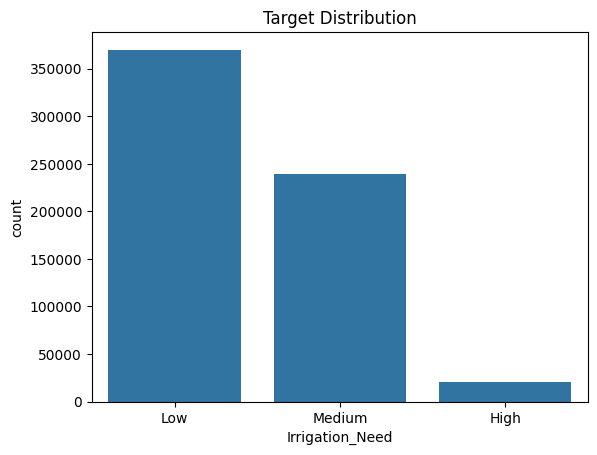

In [4]:
train['Irrigation_Need'].value_counts()

sns.countplot(x='Irrigation_Need', data=train)
plt.title("Target Distribution")
plt.show()

## 4. Preprocessing

In [13]:
X = train.drop("Irrigation_Need", axis=1)
y = train["Irrigation_Need"]

In [14]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage",
    "Season", "Irrigation_Type", "Water_Source",
    "Mulching_Used", "Region"
]

# Apply LabelEncoder to each categorical column
for col in categorical_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))


## 5. Train/Validation Split

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 6. Model Training

In [16]:
model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

In [17]:
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.056876 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2949
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 20
[LightGBM] [Info] Start training from score -3.400781
[LightGBM] [Info] Start training from score -0.532440
[LightGBM] [Info] Start training from score -0.968948


LGBMClassifier(learning_rate=0.05, n_estimators=500, random_state=42)

## 7. Validation

In [18]:
val_preds = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_preds))
print("Validation F1:", f1_score(y_val, val_preds, average='weighted'))
print(classification_report(y_val, val_preds))

Validation Accuracy: 0.9852222222222222
Validation F1: 0.9851742545819917
              precision    recall  f1-score   support

        High       0.96      0.93      0.94      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.97      0.97    126000
weighted avg       0.99      0.99      0.99    126000



## 8. Feature Importance

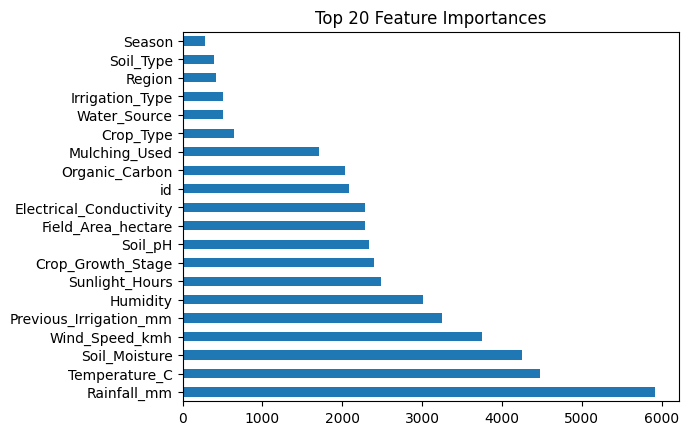

In [24]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances")
plt.show()

### The feature importance plot adds valuable interpretability:

#### 🌧️ Rainfall_mm, 🌡️ Temperature_C, and 💧 Soil_Moisture dominate the predictive power, confirming that environmental and hydrological factors drive irrigation demand.

#### Secondary contributors like Wind_Speed_kmh, Humidity, and Previous_Irrigation_mm refine the model’s sensitivity to microclimatic variations.

#### Lower-ranked features such as Season, Soil_Type, and Region still provide contextual signals but could be simplified or grouped for efficiency.

#### Together, these results indicate a model that’s not only accurate but also aligned with agronomic logic — rainfall and soil moisture are the most decisive indicators, just as field experts would expect. 



## 9. Predict on Test Set

In [23]:
test_preds = model.predict(test)

submission = pd.DataFrame({
    "id": test["id"],  
    "Irrigation_Need": test_preds
})

submission.to_csv("submission.csv", index=False)
print("Submission file created: submission.csv")

Submission file created: submission.csv
